In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time

In [2]:
df = pd.read_csv("train.csv")

df.replace("?", np.nan, inplace=True)

print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include='all'))

print("\nMissing Values:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0].sort_values(ascending=False))

First 5 Rows:


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28



Dataset Shape:
(30000, 24)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2          

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,30000,30000,29947,30000.000000,2.542400e+04,28317,30000,22730,30000,30000.000000,...,28297.000000,30000.000000,28434,30000.000000,2.515000e+04,30000.000000,29644,30000.000000,3.000000e+04,29660.000000
unique,30000,30000,2,NaN,NaN,2,8,18,3,NaN,...,NaN,NaN,3,NaN,NaN,NaN,3,NaN,NaN,NaN
top,C-36995,Frederica Shealy,M,NaN,NaN,Low,Working,Laborers,Semi-Urban,NaN,...,NaN,NaN,Active,NaN,NaN,NaN,Semi-Urban,NaN,NaN,NaN
freq,1,1,15053,NaN,NaN,25751,16926,5578,21563,NaN,...,NaN,NaN,9771,NaN,NaN,NaN,10387,NaN,NaN,NaN
mean,NaN,NaN,NaN,40.092300,2.630574e+03,NaN,NaN,NaN,NaN,88826.333855,...,739.885381,0.193933,NaN,501.934700,2.631119e+03,2.460067,NaN,-4.743867,1.317597e+05,47649.342208
std,NaN,NaN,NaN,16.045129,1.126272e+04,NaN,NaN,NaN,NaN,59536.949605,...,72.163846,0.395384,NaN,288.158086,1.132268e+04,1.118562,NaN,74.614593,9.354955e+04,48221.146686
min,NaN,NaN,NaN,18.000000,3.777000e+02,NaN,NaN,NaN,NaN,6048.240000,...,580.000000,0.000000,NaN,1.000000,3.777000e+02,1.000000,NaN,-999.000000,-9.990000e+02,-999.000000
25%,NaN,NaN,NaN,25.000000,1.650457e+03,NaN,NaN,NaN,NaN,41177.755000,...,681.880000,0.000000,NaN,251.000000,1.650450e+03,1.000000,NaN,1.000000,6.057216e+04,0.000000
50%,NaN,NaN,NaN,40.000000,2.222435e+03,NaN,NaN,NaN,NaN,75128.075000,...,739.820000,0.000000,NaN,504.000000,2.223250e+03,2.000000,NaN,1.000000,1.099936e+05,35209.395000
75%,NaN,NaN,NaN,55.000000,3.090593e+03,NaN,NaN,NaN,NaN,119964.605000,...,799.120000,0.000000,NaN,751.000000,3.091408e+03,3.000000,NaN,1.000000,1.788807e+05,74261.250000



Missing Values:


Type of Employment             7270
Property Age                   4850
Income (USD)                   4576
Dependents                     2493
Credit Score                   1703
Income Stability               1683
Has Active Credit Card         1566
Property Location               356
Loan Sanction Amount (USD)      340
Current Loan Expenses (USD)     172
Gender                           53
dtype: int64

In [3]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    negatives = (df[col] < 0).sum()
    if negatives > 0:
        print(f"{col}: {negatives} negative values")
        print(df[df[col] < 0][col].unique())
        print("-" * 50)

Current Loan Expenses (USD): 177 negative values
[-999.]
--------------------------------------------------
Co-Applicant: 168 negative values
[-999]
--------------------------------------------------
Property Price: 352 negative values
[-999.]
--------------------------------------------------
Loan Sanction Amount (USD): 338 negative values
[-999.]
--------------------------------------------------


In [4]:

cols_with_invalid = [
    "Current Loan Expenses (USD)",
    "Co-Applicant",
    "Property Price",
    "Loan Sanction Amount (USD)"
]

df[cols_with_invalid] = df[cols_with_invalid].replace(-999, np.nan)

df.dropna(subset=["Loan Sanction Amount (USD)"], inplace=True)

df.drop(columns=["Customer ID", "Name", "Property ID"], inplace=True)

X = df.drop("Loan Sanction Amount (USD)", axis=1)
y = df["Loan Sanction Amount (USD)"]

X["Co-Applicant"] = X["Co-Applicant"].astype("object")

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

# One-Hot Encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)
print("Remaining Missing Values:", X.isnull().sum().sum())

Feature Matrix Shape: (29322, 45)
Target Shape: (29322,)
Remaining Missing Values: 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_9256\244955275.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])


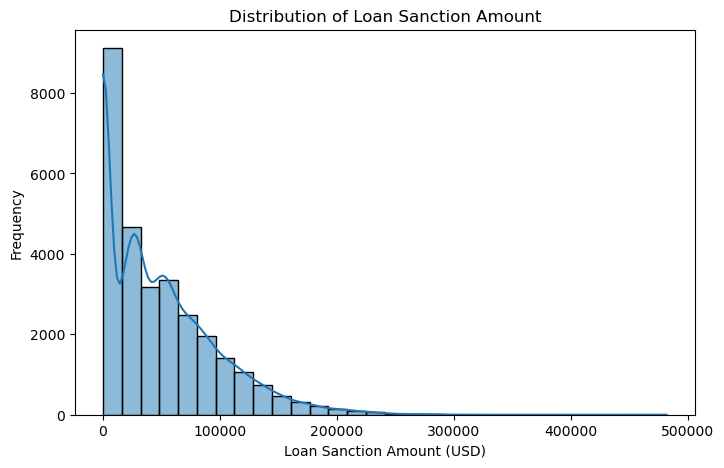

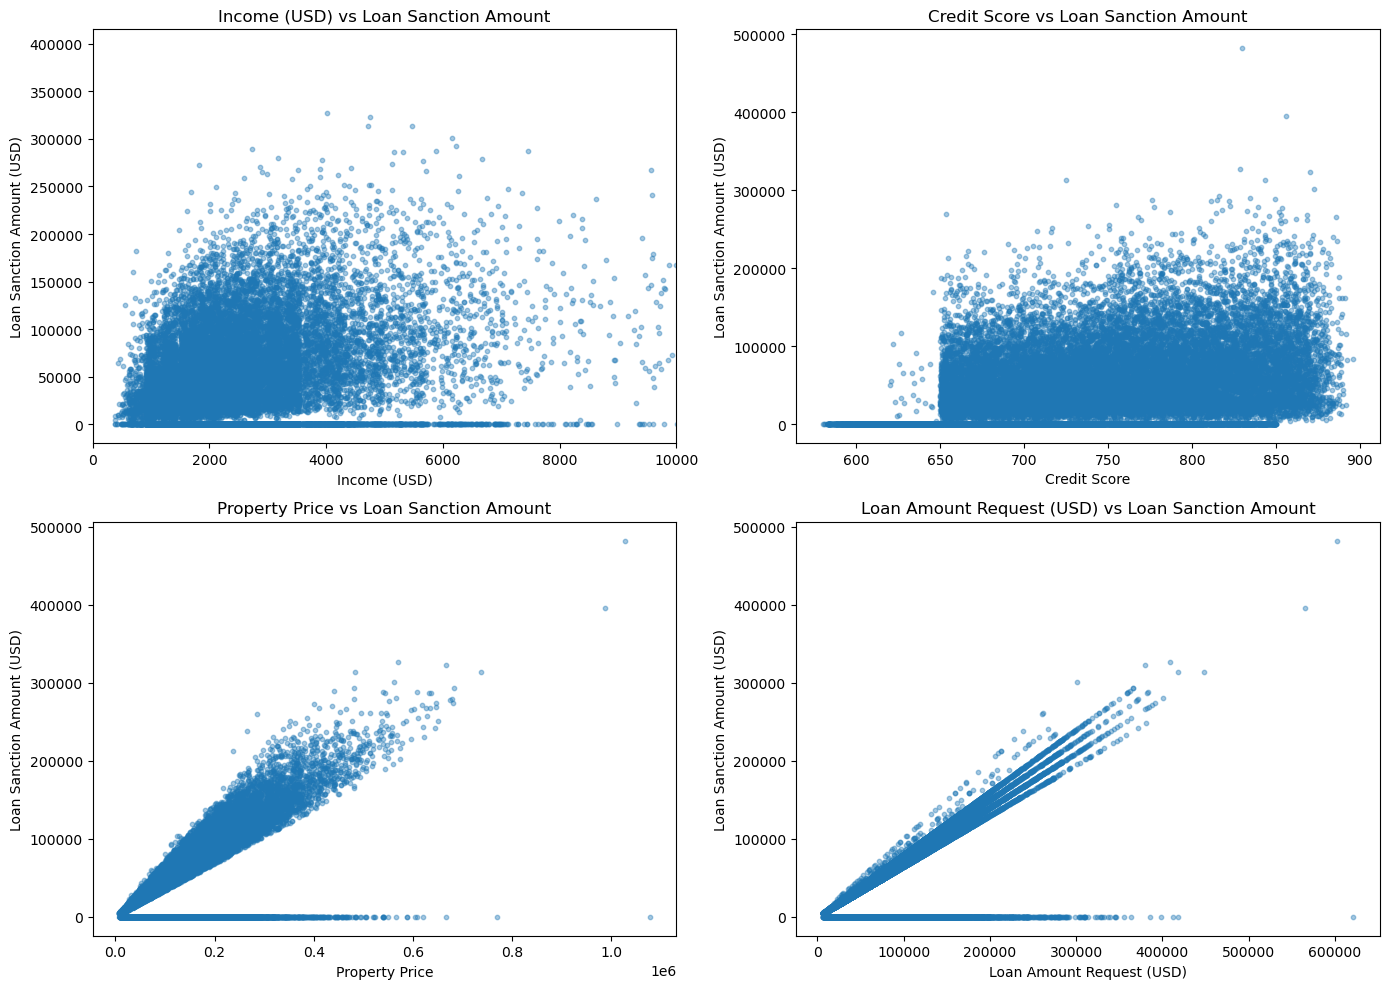

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["Loan Sanction Amount (USD)"], bins=30, kde=True)
plt.title("Distribution of Loan Sanction Amount")
plt.xlabel("Loan Sanction Amount (USD)")
plt.ylabel("Frequency")
plt.show()


features = [
    "Income (USD)",
    "Credit Score",
    "Property Price",
    "Loan Amount Request (USD)"
]

plt.figure(figsize=(14,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)

    plt.scatter(df[feature],
                df["Loan Sanction Amount (USD)"],
                alpha=0.4,
                s=10)
    if feature == "Income (USD)":
        plt.xlim(0, 10000)

    plt.title(f"{feature} vs Loan Sanction Amount")
    plt.xlabel(feature)
    plt.ylabel("Loan Sanction Amount (USD)")

plt.tight_layout()
plt.show()

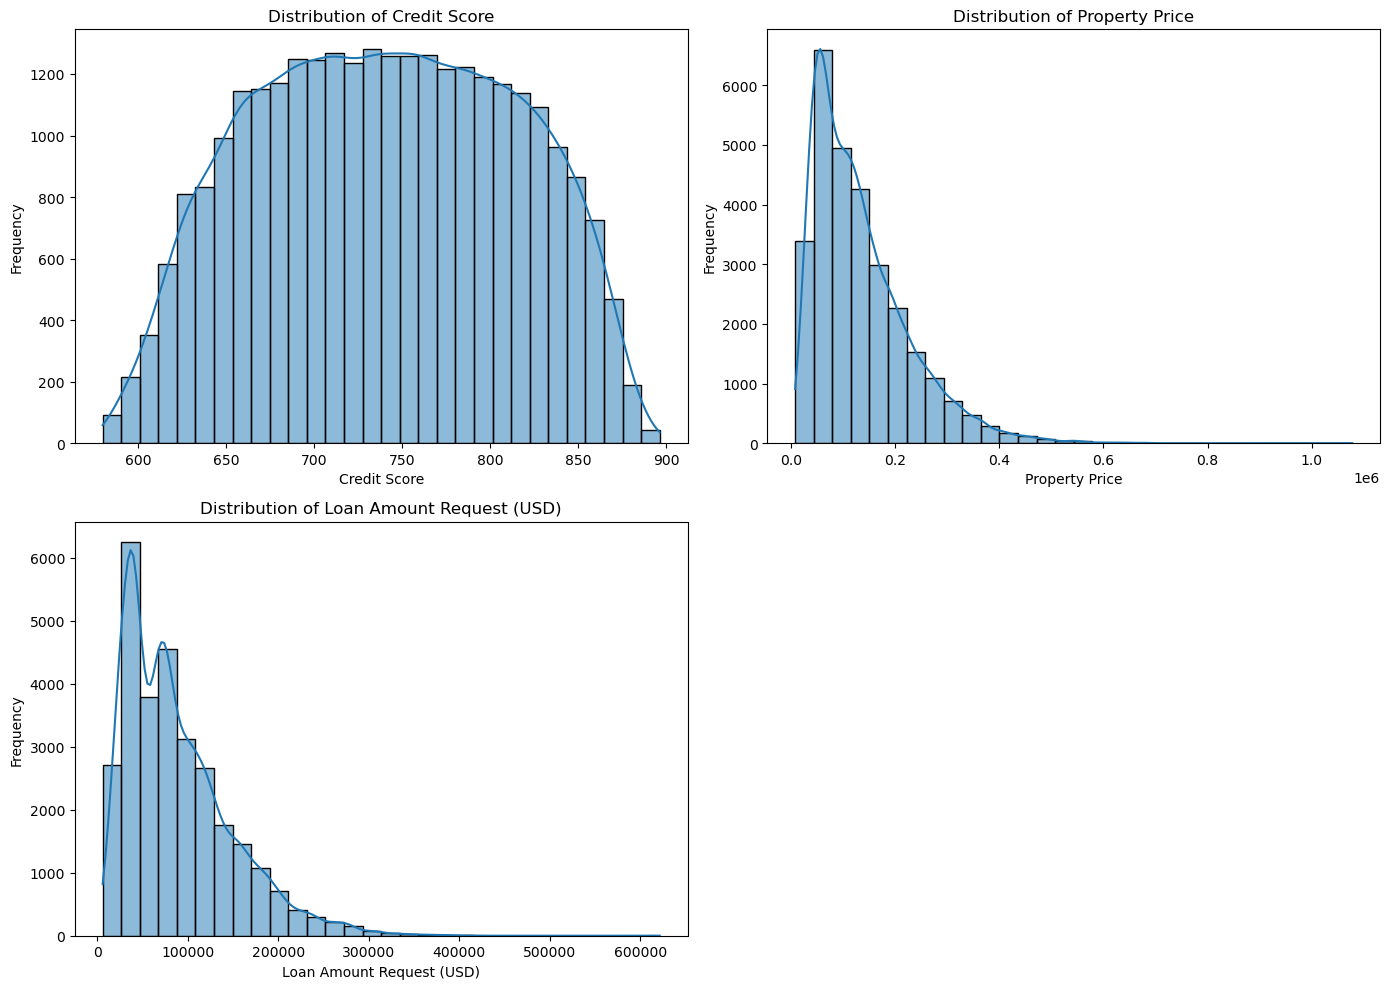

In [6]:

features = [
    
    "Credit Score",
    "Property Price",
    "Loan Amount Request (USD)"
]

plt.figure(figsize=(14,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)

    sns.histplot(df[feature], bins=30, kde=True)

    if feature == "Income (USD)":
        plt.xlim(0, 10000)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (23457, 45)
Testing Set Shape: (5865, 45)


In [8]:
import time

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

start = time.time()

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_train_time = time.time() - start

y_pred_linear = linear_model.predict(X_test_scaled)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = linear_mse ** 0.5
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print(f"MAE : {linear_mae:.2f}")
print(f"MSE : {linear_mse:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R²  : {linear_r2:.4f}")
print(f"Training Time: {linear_train_time:.4f} seconds")

Linear Regression Results
MAE : 18761.84
MSE : 770417824.65
RMSE: 27756.40
R²  : 0.6575
Training Time: 0.0133 seconds


In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

start = time.time()

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

ridge_train_time = time.time() - start

ridge_model = ridge_grid.best_estimator_

y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = ridge_mse ** 0.5
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Best Parameters:", ridge_grid.best_params_)
print("Best CV R²:", ridge_grid.best_score_)

print("\nTest Results")
print(f"MAE : {ridge_mae:.2f}")
print(f"MSE : {ridge_mse:.2f}")
print(f"RMSE: {ridge_rmse:.2f}")
print(f"R²  : {ridge_r2:.4f}")
print(f"Training Time: {ridge_train_time:.4f} seconds")

Best Parameters: {'alpha': 100}
Best CV R²: 0.6471007409102993

Test Results
MAE : 18783.05
MSE : 771227376.27
RMSE: 27770.98
R²  : 0.6571
Training Time: 0.2050 seconds


In [10]:
from sklearn.linear_model import Lasso

lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

start = time.time()

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_params,
    cv=5,
    scoring="r2"
)

lasso_grid.fit(X_train_scaled, y_train)

lasso_train_time = time.time() - start

lasso_model = lasso_grid.best_estimator_

y_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = lasso_mse ** 0.5
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Best Parameters:", lasso_grid.best_params_)
print(f"Best CV R²: {lasso_grid.best_score_:.4f}")

print("\nLasso Regression Performance")
print(f"MAE : {lasso_mae:.2f}")
print(f"MSE : {lasso_mse:.2f}")
print(f"RMSE: {lasso_rmse:.2f}")
print(f"R²  : {lasso_r2:.4f}")
print(f"Training Time: {lasso_train_time:.4f} seconds")

D:\random_driver\ANACONDA\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.329e+12, tolerance: 4.404e+09
  model = cd_fast.enet_coordinate_descent(
D:\random_driver\ANACONDA\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.956e+12, tolerance: 4.370e+09
  model = cd_fast.enet_coordinate_descent(
D:\random_driver\ANACONDA\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.541e+12, toler

Best Parameters: {'alpha': 10}
Best CV R²: 0.6452

Lasso Regression Performance
MAE : 18755.72
MSE : 770252796.35
RMSE: 27753.43
R²  : 0.6576
Training Time: 56.3093 seconds


In [11]:
from sklearn.linear_model import ElasticNet

elastic_params = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]
}

start = time.time()

elastic_grid = GridSearchCV(
    estimator=ElasticNet(max_iter=10000),
    param_grid=elastic_params,
    cv=5,
    scoring="r2"
)

elastic_grid.fit(X_train_scaled, y_train)

elastic_train_time = time.time() - start

elastic_model = elastic_grid.best_estimator_

# Predictions
y_pred_elastic = elastic_model.predict(X_test_scaled)

# Metrics
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)
elastic_mse = mean_squared_error(y_test, y_pred_elastic)
elastic_rmse = elastic_mse ** 0.5
elastic_r2 = r2_score(y_test, y_pred_elastic)

print("Best Parameters:", elastic_grid.best_params_)
print(f"Best CV R²: {elastic_grid.best_score_:.4f}")

print("\nElastic Net Regression Performance")
print(f"MAE : {elastic_mae:.2f}")
print(f"MSE : {elastic_mse:.2f}")
print(f"RMSE: {elastic_rmse:.2f}")
print(f"R²  : {elastic_r2:.4f}")
print(f"Training Time: {elastic_train_time:.4f} seconds")

Best Parameters: {'alpha': 0.1, 'l1_ratio': 0.5}
Best CV R²: 0.6534

Elastic Net Regression Performance
MAE : 19009.39
MSE : 782667586.36
RMSE: 27976.20
R²  : 0.6520
Training Time: 9.0812 seconds


In [13]:
tuning_results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net Regression"
    ],
    "Search Method": [
        "Grid Search",
        "Grid Search",
        "Grid Search"
    ],
    "Best Parameters": [
        ridge_grid.best_params_,
        lasso_grid.best_params_,
        elastic_grid.best_params_
    ],
    "Best CV R2": [
        ridge_grid.best_score_,
        lasso_grid.best_score_,
        elastic_grid.best_score_
    ]
})

display(tuning_results)

,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search,{'alpha': 100},0.647101
1,Lasso Regression,Grid Search,{'alpha': 10},0.645170
2,Elastic Net Regression,Grid Search,"{'alpha': 0.1, 'l1_ratio': 0.5}",0.653403


In [14]:
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Elastic Net Regression": elastic_model
}

cv_results = []

for name, model in models.items():

    mae = -cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    ).mean()

    mse = -cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    ).mean()

    rmse = mse ** 0.5

    r2 = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    ).mean()

    cv_results.append([name, mae, mse, rmse, r2])

cv_table = pd.DataFrame(
    cv_results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

display(cv_table)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,18903.353986,8.380704e+08,28949.446001,0.642495
1,Ridge Regression,18915.345500,8.270008e+08,28757.621400,0.647101
2,Lasso Regression,18895.336511,8.316452e+08,28838.258732,0.645170
3,Elastic Net Regression,19077.202494,8.116666e+08,28489.762402,0.653403


In [15]:
test_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net Regression"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae
    ],
    "MSE": [
        linear_mse,
        ridge_mse,
        lasso_mse,
        elastic_mse
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ],
    "Training Time (s)": [
        linear_train_time,
        ridge_train_time,
        lasso_train_time,
        elastic_train_time
    ]
})

display(test_results)

,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,Linear Regression,18761.844535,7.704178e+08,27756.401508,0.657490,0.013299
1,Ridge Regression,18783.052766,7.712274e+08,27770.980830,0.657130,0.204975
2,Lasso Regression,18755.722821,7.702528e+08,27753.428551,0.657563,56.309295
3,Elastic Net Regression,19009.394739,7.826676e+08,27976.196782,0.652044,9.081154


In [16]:
# Table 4: Coefficient Comparison

coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "Elastic Net": elastic_model.coef_
})

# Sort by importance (Linear Regression)
coef_table["Importance"] = coef_table["Linear"].abs()

coef_table = (
    coef_table
    .sort_values("Importance", ascending=False)
    .drop(columns="Importance")
    .head(10)
)

display(coef_table)

,Feature,Linear,Ridge,Lasso,Elastic Net
7,Property Age,-46437.280324,-940.614981,-17.972665,-99.291577
1,Income (USD),46415.529306,912.951138,-0.000000,61.362412
2,Loan Amount Request (USD),33139.268873,31419.584864,33113.108935,22863.946393
44,Co-Applicant_1.0,12583.362197,12523.261850,12569.472139,11945.339861
5,Credit Score,10268.767965,10248.815829,10265.513723,10008.192635
14,Profession_Pensioner,4052.963777,4472.463418,5300.429744,2837.250077
18,Profession_Working,-2786.890858,-1354.952979,-122.696990,-880.294219
11,Income Stability_Low,2522.518620,2126.030734,2235.761397,337.193521
12,Profession_Commercial associate,-2366.575799,-1087.344077,0.000000,-628.959633
15,Profession_State servant,-1508.645680,-734.005970,-60.594686,-413.920911


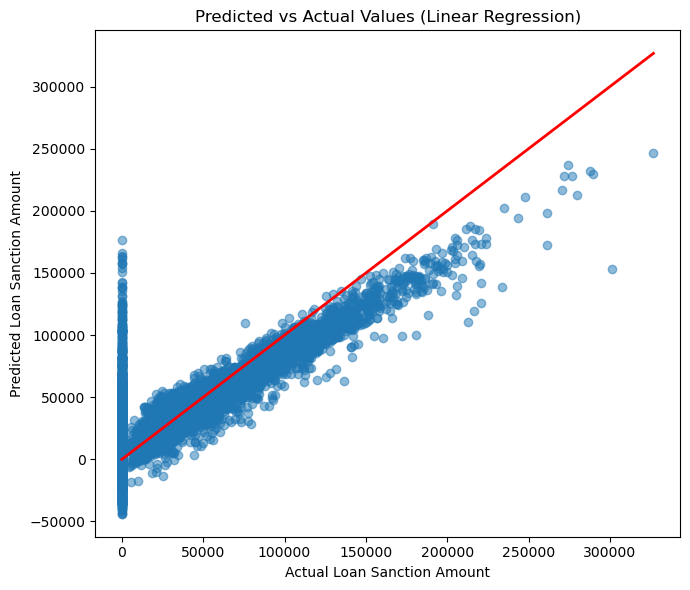

In [17]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Loan Sanction Amount")
plt.ylabel("Predicted Loan Sanction Amount")
plt.title("Predicted vs Actual Values (Linear Regression)")

plt.tight_layout()
plt.show()

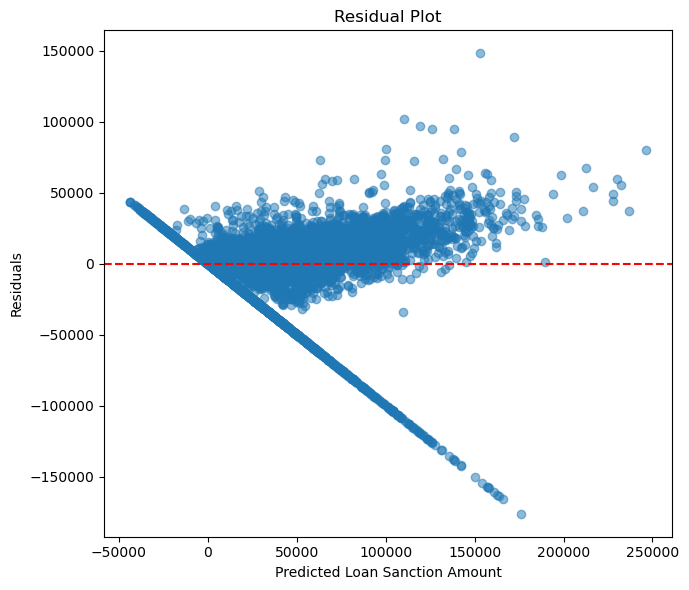

In [18]:
residuals = y_test - y_pred_linear

plt.figure(figsize=(7,6))

plt.scatter(y_pred_linear, residuals, alpha=0.5)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Loan Sanction Amount")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

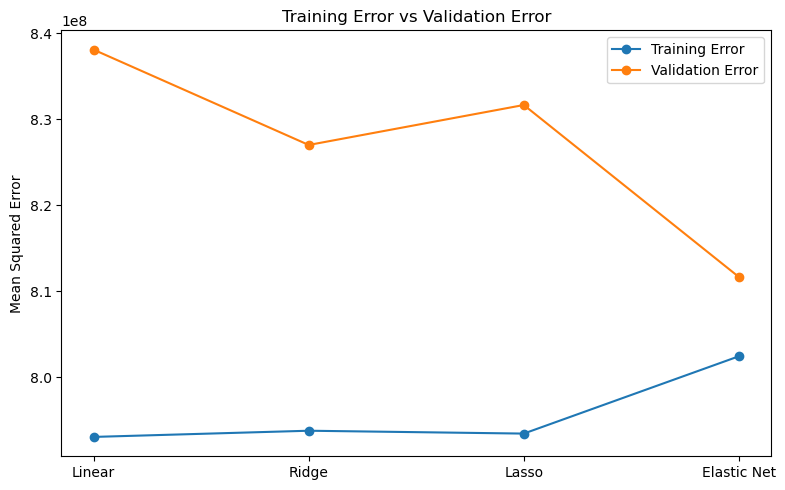

In [19]:
from sklearn.model_selection import cross_validate

models = {
    "Linear": LinearRegression(),
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Elastic Net": elastic_model
}

train_errors = []
validation_errors = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error",
        return_train_score=True
    )

    train_errors.append(-scores["train_score"].mean())
    validation_errors.append(-scores["test_score"].mean())

plt.figure(figsize=(8,5))

plt.plot(models.keys(), train_errors, marker="o", label="Training Error")
plt.plot(models.keys(), validation_errors, marker="o", label="Validation Error")

plt.title("Training Error vs Validation Error")
plt.ylabel("Mean Squared Error")
plt.legend()

plt.tight_layout()
plt.show()

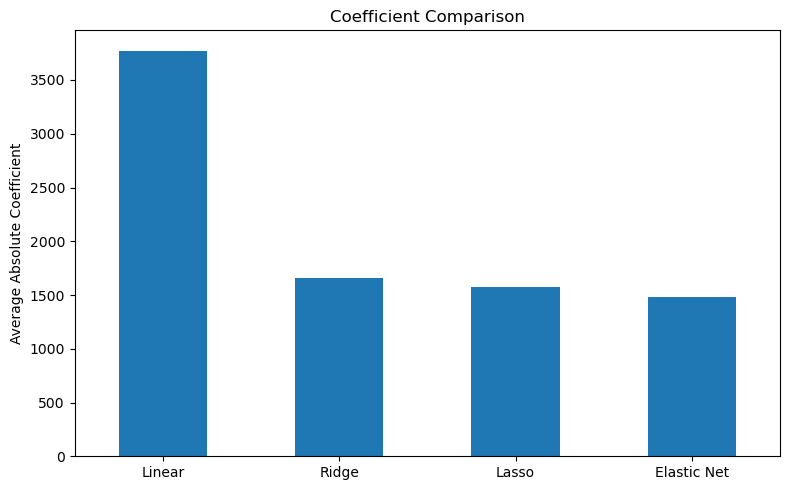

In [20]:
coef_df = pd.DataFrame({
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "Elastic Net": elastic_model.coef_
}, index=X.columns)

coef_df.abs().mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Coefficient Comparison")
plt.ylabel("Average Absolute Coefficient")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [21]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "Elastic Net": elastic_model.coef_
})

coef_table["Importance"] = coef_table["Linear"].abs()

coef_table = (
    coef_table
    .sort_values("Importance", ascending=False)
    .drop(columns="Importance")
    .head(3)
)

display(coef_table)

,Feature,Linear,Ridge,Lasso,Elastic Net
7,Property Age,-46437.280324,-940.614981,-17.972665,-99.291577
1,Income (USD),46415.529306,912.951138,-0.000000,61.362412
2,Loan Amount Request (USD),33139.268873,31419.584864,33113.108935,22863.946393
